# 02 — 延迟配送基线（Late Delivery Baseline）

## 本 notebook 要完成什么

这一本 notebook 是 **Olist Post-Purchase CX Redesign** 项目的第一层业务诊断。Notebook 01 已经完成数据 grain、join、去重和 delivery-analysis population 的验证；本 notebook 不重建这些 raw-table joins，而是直接使用已经验证的一单一行分析数据。

本 notebook 回答三个描述性问题：

1. 在可观测实际送达日期和预计送达日期的 delivered orders 中，**有多少订单晚于记录的预计送达日期？**
2. 对已经晚到的订单，**延迟通常有多严重？**
3. 在历史购买月份之间，**延迟率如何变化？**

同时，本 notebook 会描述购买日至实际送达日、购买日至预计送达日的日历天数，并显式检查 calendar-date 规则与直接 timestamp 比较之间的差异。

### 在项目故事中的位置

```text
01 数据基础与 master table
→ 02 延迟配送基线（本 notebook）
→ 03 review impact
→ 04 seller / category / region risk
→ 05–07 CX synthesis、recovery design 与未来验证
```

### Evidence boundary

本 notebook 属于 **Level 1：Direct Data Analysis**。

它可以支持关于历史延迟发生率、延迟严重程度、配送时长和时间分布的陈述；它**不能**证明 late delivery 导致低评分，也不能证明某个 seller、category 或物流环节对订单级失败负唯一责任，更不能证明未来 service recovery intervention 会有效。


## 与上游定义、Gap Matrix 和参考项目的关系

本 notebook 以 Notebook 01 的已验证定义为 source of truth：

- 主分析总体：`order_status == "delivered"`，且 actual / estimated delivery date 均可观测；
- 主 late 定义：**actual delivery calendar date > estimated delivery calendar date**；
- `delay_days`：actual delivery calendar date − estimated delivery calendar date；
- 一单一行：每个 `order_id` 在主分析中只出现一次。

参考项目只用于**方法逻辑比对**。Zeash 项目提供了 calendar-date sensitivity、severity 和月度趋势的分析思路；Moses 项目提供了先报告 delivered population 与 missing dates、再计算 delay 的简洁流程。本项目不会复制参考项目代码，也不会把参考项目已经算出的数值当成本项目结果。

本项目在这些方法上进一步强调：

- 与 Notebook 01 的字段契约保持一致；
- 每一个 percentage 都保留可追溯的 numerator / denominator；
- 月度趋势单独处理数据覆盖边界，而 overall baseline 使用完整 eligible population；
- seller / category attribution 留给后续使用正确 bridge grain 的 Notebook 04；
- 描述性结果与服务设计解释、未来 intervention validation 明确分层。


## 0. Setup

代码使用相对项目路径。Notebook 从项目根目录或 `notebooks/` 目录运行时，都应自动找到 `data/processed/`，并把结果保存到 `outputs/tables/` 和 `outputs/figures/`。

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

import matplotlib.pyplot as plt
import warnings

# 忽略字体查找警告
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# 设置中文字体（macOS 系统）
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


def find_project_root(start=None):
    """向上查找同时包含两个 processed 输入文件的项目根目录。"""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        processed = candidate / "data" / "processed"
        if (
            (processed / "analysis_orders.csv").exists()
            and (processed / "master_order_table.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "找不到项目根目录：需要 data/processed/analysis_orders.csv 和 "
        "data/processed/master_order_table.csv。"
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_PATH = PROCESSED_DIR / "analysis_orders.csv"
MASTER_PATH = PROCESSED_DIR / "master_order_table.csv"

validation_rows = []


def add_validation(check, value, expected, passed, critical=True, note=""):
    """把运行时检查记录到最终 validation table。"""
    status = "PASS" if bool(passed) else ("FAIL" if critical else "WARN")
    validation_rows.append({
        "check": check,
        "value": value,
        "expected": expected,
        "critical": bool(critical),
        "status": status,
        "note": note,
    })


def to_nullable_boolean(series, column_name):
    """安全地把 CSV 中的 True/False/空值统一为 pandas nullable boolean。"""
    mapping = {
        True: True, False: False,
        "True": True, "False": False,
        "true": True, "false": False,
        1: True, 0: False,
        1.0: True, 0.0: False,
    }
    converted = series.map(mapping)
    unknown = series.notna() & converted.isna()
    assert not unknown.any(), f"{column_name} 出现无法识别的布尔值"
    return converted.astype("boolean")


print("项目根目录：", PROJECT_ROOT)
print("主分析输入：", ANALYSIS_PATH.relative_to(PROJECT_ROOT))
print("总体审计输入：", MASTER_PATH.relative_to(PROJECT_ROOT))


项目根目录： /Users/liyouming/Documents/Work/2026:-9/Project_01/olist-post-purchase-cx-redesign
主分析输入： data/processed/analysis_orders.csv
总体审计输入： data/processed/master_order_table.csv


## 1. 读取主分析输入并验证 upstream contract

`analysis_orders.csv` 是本 notebook 的主要分析输入。`master_order_table.csv` 只用于两件事：

1. 核对 eligible / excluded population 是否与全部 99,441 个订单一致；
2. 为月度趋势计算每个 purchase month 的全部订单量与 eligibility coverage。

为了降低误用 review outcome 的风险，本 notebook **不读取 review score、review text 或 payment 字段**。它也不会 join `order_seller_bridge` 或 `order_category_bridge`；因此 overall late rate 始终保持 one-row-per-order grain。


In [14]:
analysis_columns = [
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "actual_delivery_date",
    "estimated_delivery_date",
    "delivery_analysis_eligible",
    "delay_days",
    "is_late",
    "is_late_timestamp_rule",
    "delay_band",
    "seller_count",
    "category_count",
    "is_multi_seller",
    "is_multi_category",
]

master_columns = [
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_analysis_eligible",
]

analysis_date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "actual_delivery_date",
    "estimated_delivery_date",
]
master_date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

analysis_orders = pd.read_csv(
    ANALYSIS_PATH,
    usecols=analysis_columns,
    parse_dates=analysis_date_columns,
    low_memory=False,
)
master_orders = pd.read_csv(
    MASTER_PATH,
    usecols=master_columns,
    parse_dates=master_date_columns,
    low_memory=False,
)

for column in ["delivery_analysis_eligible", "is_late", "is_late_timestamp_rule", "is_multi_seller", "is_multi_category"]:
    analysis_orders[column] = to_nullable_boolean(analysis_orders[column], column)
master_orders["delivery_analysis_eligible"] = to_nullable_boolean(
    master_orders["delivery_analysis_eligible"], "delivery_analysis_eligible"
)

input_summary = pd.DataFrame([
    {
        "dataset": "analysis_orders",
        "rows": len(analysis_orders),
        "unique_order_id": analysis_orders["order_id"].nunique(),
        "duplicate_order_id_rows": int(analysis_orders["order_id"].duplicated().sum()),
    },
    {
        "dataset": "master_order_table",
        "rows": len(master_orders),
        "unique_order_id": master_orders["order_id"].nunique(),
        "duplicate_order_id_rows": int(master_orders["order_id"].duplicated().sum()),
    },
])

display(input_summary)

add_validation(
    "analysis_orders 当前快照行数",
    len(analysis_orders),
    96470,
    len(analysis_orders) == 96470,
)
add_validation(
    "analysis_orders 一单一行",
    int(analysis_orders["order_id"].duplicated().sum()),
    0,
    analysis_orders["order_id"].is_unique and analysis_orders["order_id"].notna().all(),
)
add_validation(
    "master_order_table 当前快照行数",
    len(master_orders),
    99441,
    len(master_orders) == 99441,
)
add_validation(
    "master_order_table 一单一行",
    int(master_orders["order_id"].duplicated().sum()),
    0,
    master_orders["order_id"].is_unique and master_orders["order_id"].notna().all(),
)

assert len(analysis_orders) == 96470
assert analysis_orders["order_id"].is_unique
assert len(master_orders) == 99441
assert master_orders["order_id"].is_unique


,dataset,rows,unique_order_id,duplicate_order_id_rows
0,analysis_orders,96470,96470,0
1,master_order_table,99441,99441,0


## 2. Delivery-analysis population 与分母审计

主分析总体继续沿用 Notebook 01：

```text
order_status == "delivered"
AND order_delivered_customer_date is not null
AND order_estimated_delivery_date is not null
```

这里不把 excluded orders 当作 on-time，也不假设缺失是随机的。为了让分母可追溯，使用 master table 将全部订单划分为互斥类别：

1. eligible delivery-analysis orders；
2. 非 delivered orders；
3. delivered 但缺 actual delivery date；
4. delivered 且有 actual date，但缺 estimated delivery date。

这些分区必须完整覆盖 master table，并且 Notebook 01 保存的 eligibility flag 必须与重新计算结果一致。


In [15]:
master_eligible_recalc = (
    master_orders["order_status"].eq("delivered")
    & master_orders["order_delivered_customer_date"].notna()
    & master_orders["order_estimated_delivery_date"].notna()
)

excluded_non_delivered = master_orders["order_status"].ne("delivered")
excluded_missing_actual = (
    master_orders["order_status"].eq("delivered")
    & master_orders["order_delivered_customer_date"].isna()
)
excluded_missing_estimated = (
    master_orders["order_status"].eq("delivered")
    & master_orders["order_delivered_customer_date"].notna()
    & master_orders["order_estimated_delivery_date"].isna()
)

partition_masks = {
    "eligible_delivery_analysis": master_eligible_recalc,
    "excluded_non_delivered": excluded_non_delivered,
    "excluded_delivered_missing_actual_date": excluded_missing_actual,
    "excluded_delivered_missing_estimated_date": excluded_missing_estimated,
}

partition_total = sum(int(mask.sum()) for mask in partition_masks.values())
assert partition_total == len(master_orders), "Population 分区没有完整覆盖 master table"
assert sum(mask.astype(int) for mask in partition_masks.values()).max() == 1, "Population 分区发生重叠"

flag_matches = (
    master_orders["delivery_analysis_eligible"].fillna(False).astype(bool)
    == master_eligible_recalc
).all()
assert flag_matches, "Notebook 01 保存的 eligibility flag 与当前定义不一致"

analysis_id_set = set(analysis_orders["order_id"])
eligible_id_set = set(master_orders.loc[master_eligible_recalc, "order_id"])
assert analysis_id_set == eligible_id_set, "analysis_orders 与 master eligible order_id 集合不一致"

population_rows = [
    {
        "record_type": "total",
        "population": "all_orders",
        "orders": len(master_orders),
        "pct_of_all_orders": 100.0,
        "definition": "master_order_table 中全部订单",
    }
]

population_definitions = {
    "eligible_delivery_analysis": "delivered 且 actual / estimated delivery date 均非空",
    "excluded_non_delivered": "order_status 不是 delivered",
    "excluded_delivered_missing_actual_date": "delivered 但缺 actual delivery date",
    "excluded_delivered_missing_estimated_date": "delivered、有 actual date，但缺 estimated delivery date",
}

for name, mask in partition_masks.items():
    count = int(mask.sum())
    population_rows.append({
        "record_type": "partition",
        "population": name,
        "orders": count,
        "pct_of_all_orders": 100 * count / len(master_orders),
        "definition": population_definitions[name],
    })

population_audit = pd.DataFrame(population_rows)
population_audit["pct_of_all_orders"] = population_audit["pct_of_all_orders"].round(3)
population_audit.to_csv(TABLE_DIR / "02_population_audit.csv", index=False)

display(population_audit)

add_validation("eligible 分区订单数", int(master_eligible_recalc.sum()), 96470, int(master_eligible_recalc.sum()) == 96470)
add_validation("population 分区完整覆盖 master", partition_total, len(master_orders), partition_total == len(master_orders))
add_validation("upstream eligibility flag 与重新计算一致", int(flag_matches), True, flag_matches)
add_validation("analysis_orders order_id 与 master eligible 集合一致", len(analysis_id_set), len(eligible_id_set), analysis_id_set == eligible_id_set)
add_validation("analysis_orders 全部为 delivered", int(analysis_orders["order_status"].ne("delivered").sum()), 0, analysis_orders["order_status"].eq("delivered").all())
add_validation("analysis_orders 缺 actual delivery timestamp", int(analysis_orders["order_delivered_customer_date"].isna().sum()), 0, analysis_orders["order_delivered_customer_date"].notna().all())
add_validation("analysis_orders 缺 estimated delivery timestamp", int(analysis_orders["order_estimated_delivery_date"].isna().sum()), 0, analysis_orders["order_estimated_delivery_date"].notna().all())

assert analysis_orders["order_status"].eq("delivered").all()
assert analysis_orders["order_delivered_customer_date"].notna().all()
assert analysis_orders["order_estimated_delivery_date"].notna().all()


,record_type,population,orders,pct_of_all_orders,definition
0,total,all_orders,99441,100.000,master_order_table 中全部订单
1,partition,eligible_delivery_analysis,96470,97.012,delivered 且 actual / estimated delivery date 均非空
2,partition,excluded_non_delivered,2963,2.980,order_status 不是 delivered
3,partition,excluded_delivered_missing_actual_date,8,0.008,delivered 但缺 actual delivery date
4,partition,excluded_delivered_missing_estimated_date,0,0.000,delivered、有 actual date，但缺 estimated delivery date


## 3. 日期、late definition 与 upstream 字段一致性

主定义使用**日历日期比较**，而不是直接比较 timestamp：

```text
actual delivery calendar date > estimated delivery calendar date
```

原因是 `order_estimated_delivery_date` 在这套数据中表达的是预计送达的日历日。若把实际送达时间（例如当天 18:00）直接与预计日期午夜（00:00）比较，会把“承诺日当天送达”的订单误判为 late。

本节不会建立新的业务定义，而是从原始 timestamp 重新推导 calendar date、`delay_days` 和 late flag，用来检查 Notebook 01 已保存字段是否完全一致。

此外，本节创建两个描述性时长：

- `actual_delivery_duration_days`：购买日 → 实际送达日；
- `estimated_delivery_duration_days`：购买日 → 记录的预计送达日。

它们都使用 calendar-date difference，以避免混合不同时间精度。


In [16]:
# 重新从 timestamp 得到日历日期，作为独立 validation 路径。
recalc_actual_date = analysis_orders["order_delivered_customer_date"].dt.normalize()
recalc_estimated_date = analysis_orders["order_estimated_delivery_date"].dt.normalize()
recalc_purchase_date = analysis_orders["order_purchase_timestamp"].dt.normalize()

stored_actual_date = analysis_orders["actual_delivery_date"].dt.normalize()
stored_estimated_date = analysis_orders["estimated_delivery_date"].dt.normalize()

actual_date_matches = recalc_actual_date.equals(stored_actual_date)
estimated_date_matches = recalc_estimated_date.equals(stored_estimated_date)
assert actual_date_matches, "actual_delivery_date 与原始 timestamp 的 calendar date 不一致"
assert estimated_date_matches, "estimated_delivery_date 与原始 timestamp 的 calendar date 不一致"

recalc_delay_days = (recalc_actual_date - recalc_estimated_date).dt.days
recalc_is_late = recalc_actual_date > recalc_estimated_date
recalc_timestamp_late = (
    analysis_orders["order_delivered_customer_date"]
    > analysis_orders["order_estimated_delivery_date"]
)

stored_is_late = analysis_orders["is_late"].astype(bool)
stored_timestamp_late = analysis_orders["is_late_timestamp_rule"].astype(bool)

assert recalc_delay_days.equals(analysis_orders["delay_days"].astype(int)), "delay_days 与 calendar-date difference 不一致"
assert np.array_equal(recalc_is_late.to_numpy(), stored_is_late.to_numpy()), "is_late 与 calendar-date 规则不一致"
assert np.array_equal(recalc_timestamp_late.to_numpy(), stored_timestamp_late.to_numpy()), "timestamp sensitivity flag 不一致"

# Calendar-late 必须是 timestamp-late 的子集；两者的差异只能来自同一日历日送达。
calendar_not_timestamp = recalc_is_late & ~recalc_timestamp_late
same_day_timestamp_only = recalc_timestamp_late & ~recalc_is_late
assert not calendar_not_timestamp.any(), "出现 calendar late 但 timestamp 不 late 的逻辑矛盾"
assert (recalc_actual_date[same_day_timestamp_only] == recalc_estimated_date[same_day_timestamp_only]).all(), "两种规则的差异不只来自同日送达"

analysis = analysis_orders.copy()
analysis["actual_delivery_duration_days"] = (recalc_actual_date - recalc_purchase_date).dt.days
analysis["estimated_delivery_duration_days"] = (recalc_estimated_date - recalc_purchase_date).dt.days

# 一个很重要的恒等式：实际时长 - 预计时长 = delay_days。
duration_identity = (
    analysis["actual_delivery_duration_days"]
    - analysis["estimated_delivery_duration_days"]
).equals(analysis["delay_days"].astype(int))
assert duration_identity, "配送时长与 delay_days 的关系不一致"

calendar_late_orders = int(recalc_is_late.sum())
timestamp_late_orders = int(recalc_timestamp_late.sum())
eligible_orders = len(analysis)
calendar_late_rate = 100 * calendar_late_orders / eligible_orders
timestamp_late_rate = 100 * timestamp_late_orders / eligible_orders
same_day_only_orders = int(same_day_timestamp_only.sum())

sensitivity = pd.DataFrame([
    {
        "definition": "primary_calendar_date_rule",
        "eligible_orders": eligible_orders,
        "late_orders": calendar_late_orders,
        "late_rate_pct": calendar_late_rate,
        "difference_vs_primary_pp": 0.0,
        "same_day_only_orders": 0,
    },
    {
        "definition": "naive_raw_timestamp_rule",
        "eligible_orders": eligible_orders,
        "late_orders": timestamp_late_orders,
        "late_rate_pct": timestamp_late_rate,
        "difference_vs_primary_pp": timestamp_late_rate - calendar_late_rate,
        "same_day_only_orders": same_day_only_orders,
    },
])

sensitivity[["late_rate_pct", "difference_vs_primary_pp"]] = sensitivity[["late_rate_pct", "difference_vs_primary_pp"]].round(3)
sensitivity.to_csv(TABLE_DIR / "02_date_rule_sensitivity.csv", index=False)
display(sensitivity)

add_validation("actual_delivery_date 与原始 timestamp 日期一致", int(actual_date_matches), True, actual_date_matches)
add_validation("estimated_delivery_date 与原始 timestamp 日期一致", int(estimated_date_matches), True, estimated_date_matches)
add_validation("delay_days 与重新计算 calendar difference 一致", int((recalc_delay_days == analysis["delay_days"]).all()), True, (recalc_delay_days == analysis["delay_days"]).all())
add_validation("is_late 与 calendar-date 规则一致", int(np.array_equal(recalc_is_late.to_numpy(), stored_is_late.to_numpy())), True, np.array_equal(recalc_is_late.to_numpy(), stored_is_late.to_numpy()))
add_validation("calendar late 是 timestamp late 的子集", int(not calendar_not_timestamp.any()), True, not calendar_not_timestamp.any())
add_validation("两种 late 规则的差异均为同日送达", same_day_only_orders, "全部满足 actual_date == estimated_date", (recalc_actual_date[same_day_timestamp_only] == recalc_estimated_date[same_day_timestamp_only]).all())
add_validation("配送时长恒等式成立", int(duration_identity), True, duration_identity)


,definition,eligible_orders,late_orders,late_rate_pct,difference_vs_primary_pp,same_day_only_orders
0,primary_calendar_date_rule,96470,6534,6.773,0.000,0
1,naive_raw_timestamp_rule,96470,7826,8.112,1.339,1292


## 4. Overall late-delivery baseline

这一节只回答“在 eligible delivered orders 中，有多少订单晚于记录的预计送达日期”。

分母固定为全部 eligible orders；分子固定为 calendar-date rule 下的 late orders。不会在这一节因为 review 是否存在、seller 数量或 category 数量而改变总体。

`02_delivery_baseline_summary.csv` 是后续 Notebook、报告和 dashboard 可以复用的基线表。所有 `_pct` 字段均使用 **0–100 百分数单位**。


In [17]:
late_mask = recalc_is_late
late_orders = analysis.loc[late_mask].copy()
on_time_or_early_orders = int((~late_mask).sum())

baseline_summary = pd.DataFrame([{
    "population": "eligible_delivered_orders",
    "eligible_orders": eligible_orders,
    "late_orders": calendar_late_orders,
    "on_time_or_early_orders": on_time_or_early_orders,
    "late_rate_pct": calendar_late_rate,
    "mean_delay_days_late": late_orders["delay_days"].mean(),
    "median_delay_days_late": late_orders["delay_days"].median(),
    "p90_delay_days_late": late_orders["delay_days"].quantile(0.90),
    "max_delay_days_late": late_orders["delay_days"].max(),
    "mean_actual_delivery_duration_days": analysis["actual_delivery_duration_days"].mean(),
    "median_actual_delivery_duration_days": analysis["actual_delivery_duration_days"].median(),
    "mean_estimated_delivery_duration_days": analysis["estimated_delivery_duration_days"].mean(),
    "median_estimated_delivery_duration_days": analysis["estimated_delivery_duration_days"].median(),
}])

numeric_round_cols = [
    "late_rate_pct",
    "mean_delay_days_late",
    "median_delay_days_late",
    "p90_delay_days_late",
    "mean_actual_delivery_duration_days",
    "median_actual_delivery_duration_days",
    "mean_estimated_delivery_duration_days",
    "median_estimated_delivery_duration_days",
]
baseline_summary[numeric_round_cols] = baseline_summary[numeric_round_cols].round(2)
baseline_summary.to_csv(TABLE_DIR / "02_delivery_baseline_summary.csv", index=False)

display(baseline_summary.T.rename(columns={0: "value"}))

add_validation(
    "late + on-time/early = eligible",
    calendar_late_orders + on_time_or_early_orders,
    eligible_orders,
    calendar_late_orders + on_time_or_early_orders == eligible_orders,
)
add_validation(
    "late flag 与 delay_days > 0 等价",
    int((analysis["delay_days"].gt(0) == late_mask).all()),
    True,
    (analysis["delay_days"].gt(0) == late_mask).all(),
)

assert calendar_late_orders + on_time_or_early_orders == eligible_orders
assert (analysis["delay_days"].gt(0) == late_mask).all()


,value
population,eligible_delivered_orders
eligible_orders,96470
late_orders,6534
on_time_or_early_orders,89936
late_rate_pct,6.770
mean_delay_days_late,10.620
median_delay_days_late,7.000
p90_delay_days_late,22.000
max_delay_days_late,188
mean_actual_delivery_duration_days,12.500


## 5. Delay severity

总体 late rate 描述“发生了多少次 missed estimated date”；severity 描述“晚了多少天”。

本 notebook 继续使用 Notebook 01 的六档标准，不建立第二套分档：

| Severity band | `delay_days` |
|---|---:|
| on time or early | ≤ 0 |
| 1–3 days late | 1–3 |
| 4–7 days late | 4–7 |
| 8–14 days late | 8–14 |
| 15–30 days late | 15–30 |
| 31+ days late | ≥ 31 |

每一档同时报告：

- 订单数；
- 占全部 eligible orders 的比例；
- 对 late bands，额外报告占全部 late orders 的比例。

这些分档是**描述性分析类别**，不是已经验证的补偿阈值或客户伤害阈值。


In [18]:
severity_order = [
    "on time or early",
    "1-3 days late",
    "4-7 days late",
    "8-14 days late",
    "15-30 days late",
    "31+ days late",
]

recalc_band = pd.Series(index=analysis.index, dtype="string")
recalc_band.loc[analysis["delay_days"] <= 0] = "on time or early"
recalc_band.loc[analysis["delay_days"].between(1, 3)] = "1-3 days late"
recalc_band.loc[analysis["delay_days"].between(4, 7)] = "4-7 days late"
recalc_band.loc[analysis["delay_days"].between(8, 14)] = "8-14 days late"
recalc_band.loc[analysis["delay_days"].between(15, 30)] = "15-30 days late"
recalc_band.loc[analysis["delay_days"] >= 31] = "31+ days late"

band_matches = recalc_band.fillna("<missing>").equals(analysis["delay_band"].astype("string").fillna("<missing>"))
assert band_matches, "重新计算的 severity band 与 Notebook 01 保存字段不一致"
assert recalc_band.notna().all(), "存在无法归入 severity band 的 eligible order"

severity_counts = recalc_band.value_counts().reindex(severity_order, fill_value=0)
severity = pd.DataFrame({
    "severity_band": severity_order,
    "sort_order": range(1, len(severity_order) + 1),
    "orders": [int(severity_counts[label]) for label in severity_order],
})
severity["pct_of_eligible_orders"] = 100 * severity["orders"] / eligible_orders
severity["pct_of_late_orders"] = np.where(
    severity["severity_band"].eq("on time or early"),
    np.nan,
    100 * severity["orders"] / calendar_late_orders,
)
severity[["pct_of_eligible_orders", "pct_of_late_orders"]] = severity[["pct_of_eligible_orders", "pct_of_late_orders"]].round(2)
severity.to_csv(TABLE_DIR / "02_delay_severity.csv", index=False)

display(severity)

late_band_total = int(severity.loc[severity["severity_band"] != "on time or early", "orders"].sum())
add_validation("severity band 覆盖全部 eligible orders", int(severity["orders"].sum()), eligible_orders, int(severity["orders"].sum()) == eligible_orders)
add_validation("late severity bands 合计等于 late orders", late_band_total, calendar_late_orders, late_band_total == calendar_late_orders)
add_validation("severity band 与 Notebook 01 保存字段一致", int(band_matches), True, band_matches)
add_validation(
    "severity 占 eligible 比例合计为 100%（未四舍五入口径）",
    round(100 * severity["orders"].sum() / eligible_orders, 10),
    100.0,
    np.isclose(100 * severity["orders"].sum() / eligible_orders, 100.0),
)

assert severity["orders"].sum() == eligible_orders
assert late_band_total == calendar_late_orders


,severity_band,sort_order,orders,pct_of_eligible_orders,pct_of_late_orders
0,on time or early,1,89936,93.230,NaN
1,1-3 days late,2,1870,1.940,28.620
2,4-7 days late,3,1802,1.870,27.580
3,8-14 days late,4,1478,1.530,22.620
4,15-30 days late,5,1039,1.080,15.900
5,31+ days late,6,345,0.360,5.280


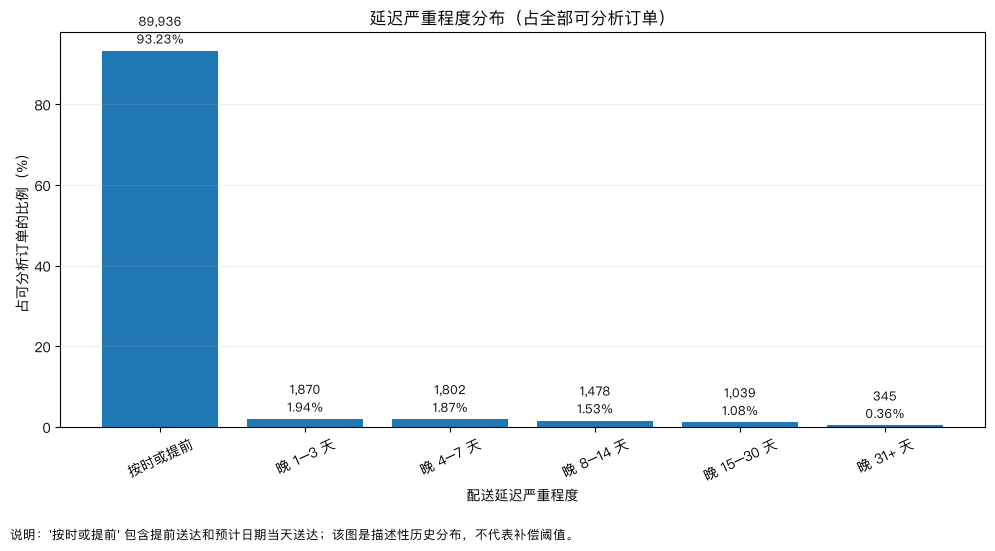

In [19]:
# 只保存一张必要的 severity 图；分母固定为全部 eligible orders。
fig, ax = plt.subplots(figsize=(10, 5.5))
severity_plot_labels = ["按时或提前", "晚 1–3 天", "晚 4–7 天", "晚 8–14 天", "晚 15–30 天", "晚 31+ 天"]
ax.bar(severity_plot_labels, severity["pct_of_eligible_orders"])
ax.set_title("延迟严重程度分布（占全部可分析订单）")
ax.set_ylabel("占可分析订单的比例（%）")
ax.set_xlabel("配送延迟严重程度")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.2)

for i, row in severity.iterrows():
    ax.text(
        i,
        row["pct_of_eligible_orders"] + 0.8,
        f'{int(row["orders"]):,}\n{row["pct_of_eligible_orders"]:.2f}%',
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.text(
    0.01,
    0.01,
    "说明：'按时或提前' 包含提前送达和预计日期当天送达；该图是描述性历史分布，不代表补偿阈值。",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.05, 1, 1])
severity_figure_path = FIGURE_DIR / "02_delay_severity.png"
fig.savefig(severity_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 6. Actual 与 estimated delivery duration

这里的两个 duration 都从**购买日**开始计算：

- actual delivery duration：购买日 → 记录的 customer delivery date；
- estimated delivery duration：购买日 → 记录的 estimated delivery date。

它们帮助描述历史履约时长和预计日期之间的总体背景，但不能直接解释成 carrier transit time，也不能据此确定哪一个内部流程造成了延迟。

由于数据只提供记录的 `order_estimated_delivery_date`，本 notebook 也不会进一步假设该日期何时、以何种方式展示给客户，或是否发生过内部更新。


In [20]:
duration_summary = pd.DataFrame([
    {
        "metric": "actual_delivery_duration_days",
        "mean": analysis["actual_delivery_duration_days"].mean(),
        "median": analysis["actual_delivery_duration_days"].median(),
        "p90": analysis["actual_delivery_duration_days"].quantile(0.90),
        "min": analysis["actual_delivery_duration_days"].min(),
        "max": analysis["actual_delivery_duration_days"].max(),
    },
    {
        "metric": "estimated_delivery_duration_days",
        "mean": analysis["estimated_delivery_duration_days"].mean(),
        "median": analysis["estimated_delivery_duration_days"].median(),
        "p90": analysis["estimated_delivery_duration_days"].quantile(0.90),
        "min": analysis["estimated_delivery_duration_days"].min(),
        "max": analysis["estimated_delivery_duration_days"].max(),
    },
]).round(2)

display(duration_summary)

negative_actual_duration = int((analysis["actual_delivery_duration_days"] < 0).sum())
negative_estimated_duration = int((analysis["estimated_delivery_duration_days"] < 0).sum())

# 负 duration 属于数据质量异常；当前快照预期为 0。若未来出现，记录为 WARN 而不是静默删除。
add_validation(
    "actual delivery duration < 0 的订单",
    negative_actual_duration,
    0,
    negative_actual_duration == 0,
    critical=False,
    note="若非 0，应先调查日期质量，不应自动删除。",
)
add_validation(
    "estimated delivery duration < 0 的订单",
    negative_estimated_duration,
    0,
    negative_estimated_duration == 0,
    critical=False,
    note="若非 0，应先调查日期质量，不应自动删除。",
)


,metric,mean,median,p90,min,max
0,actual_delivery_duration_days,12.500,10.000,23.000,0,210
1,estimated_delivery_duration_days,24.370,24.000,35.000,3,156


## 7. Monthly late-delivery patterns

月度分析按 `order_purchase_timestamp` 的购买月份分组。每个月同时保留：

- 全部订单数（来自 master table）；
- eligible delivered orders；
- late orders；
- eligibility coverage；
- late rate。

### 趋势窗口规则

为了避免把数据集边界上的不完整月份、零订单月份或极低覆盖月份与正常月份直接比较，趋势图使用一个**完全由数据覆盖决定、与 late rate 无关**的规则：

1. 首月和末月视为数据集边界月，不进入趋势候选；
2. 对其余完整月份，计算正订单量月份的中位数；
3. 以该中位数的 **10%** 作为最低月订单量覆盖门槛；
4. 在满足门槛的月份中，选择**最长连续月份区间**作为趋势窗口；
5. 所有月份仍保留在 `02_monthly_late_rate.csv`，并写明是否纳入及排除原因。

这个 10% 规则是一个透明的 coverage heuristic，不是统计显著性阈值。Overall late rate 仍然使用完整 eligible population，不受趋势窗口影响。

另外，eligibility coverage 会单独显示，因为最近购买 cohort 可能受到观察窗口结束的影响。月度差异只能描述历史 pattern，不能据此断言季节性、运营根因或因果机制。


In [21]:
assert master_orders["order_purchase_timestamp"].notna().all(), "master 中存在缺 purchase timestamp 的订单"
assert analysis["order_purchase_timestamp"].notna().all(), "analysis 中存在缺 purchase timestamp 的订单"

master_month = master_orders["order_purchase_timestamp"].dt.to_period("M")
analysis_month = analysis["order_purchase_timestamp"].dt.to_period("M")

first_month = master_month.min()
last_month = master_month.max()
month_index = pd.period_range(first_month, last_month, freq="M")

all_order_counts = master_orders.assign(purchase_month=master_month).groupby("purchase_month").size()
eligible_counts = analysis.assign(purchase_month=analysis_month).groupby("purchase_month").size()
late_counts = analysis.assign(purchase_month=analysis_month).groupby("purchase_month")["is_late"].sum()

monthly = pd.DataFrame(index=month_index)
monthly.index.name = "purchase_month"
monthly["all_orders"] = all_order_counts.reindex(month_index, fill_value=0).astype(int)
monthly["eligible_orders"] = eligible_counts.reindex(month_index, fill_value=0).astype(int)
monthly["late_orders"] = late_counts.reindex(month_index, fill_value=0).astype(int)
monthly["excluded_orders"] = monthly["all_orders"] - monthly["eligible_orders"]
monthly["eligibility_coverage_pct"] = np.where(
    monthly["all_orders"] > 0,
    100 * monthly["eligible_orders"] / monthly["all_orders"],
    np.nan,
)
monthly["late_rate_pct"] = np.where(
    monthly["eligible_orders"] > 0,
    100 * monthly["late_orders"] / monthly["eligible_orders"],
    np.nan,
)

monthly["is_boundary_month"] = monthly.index.isin([first_month, last_month])
monthly["is_full_calendar_month"] = ~monthly["is_boundary_month"]

positive_full_counts = monthly.loc[
    monthly["is_full_calendar_month"] & monthly["all_orders"].gt(0),
    "all_orders",
]
monthly_volume_median = float(positive_full_counts.median())
monthly_volume_floor = 0.10 * monthly_volume_median
monthly["volume_floor_orders"] = monthly_volume_floor
monthly["meets_volume_floor"] = (
    monthly["is_full_calendar_month"]
    & monthly["all_orders"].ge(monthly_volume_floor)
)

# 找出满足门槛的最长连续月份区间；如长度并列，确定性地取最早出现的区间。
runs = []
run_start = None
run_end = None
for period, meets in monthly["meets_volume_floor"].items():
    if meets:
        if run_start is None:
            run_start = period
        run_end = period
    elif run_start is not None:
        runs.append((run_start, run_end))
        run_start = None
        run_end = None
if run_start is not None:
    runs.append((run_start, run_end))

assert runs, "没有找到任何满足月度覆盖门槛的连续区间"
run_lengths = [end.ordinal - start.ordinal + 1 for start, end in runs]
max_length = max(run_lengths)
selected_run = next(run for run, length in zip(runs, run_lengths) if length == max_length)
trend_start, trend_end = selected_run
monthly["trend_included"] = (monthly.index >= trend_start) & (monthly.index <= trend_end) & monthly["meets_volume_floor"]


def exclusion_reason(row):
    if row["trend_included"]:
        return "纳入：完整月份、达到覆盖门槛且位于最长连续可比区间"
    if row["is_boundary_month"]:
        return "排除：数据集首/尾边界月份不完整"
    if row["all_orders"] == 0:
        return "排除：该日历月无订单记录"
    if not row["meets_volume_floor"]:
        return "排除：订单量低于覆盖门槛"
    return "排除：不在最长连续可比月份区间"


monthly["trend_exclusion_reason"] = monthly.apply(exclusion_reason, axis=1)
monthly["small_sample_warning"] = (monthly["eligible_orders"] > 0) & (monthly["eligible_orders"] < 50)

monthly_output = monthly.reset_index()
monthly_output["purchase_month"] = monthly_output["purchase_month"].astype(str)
monthly_output[["eligibility_coverage_pct", "late_rate_pct", "volume_floor_orders"]] = monthly_output[[
    "eligibility_coverage_pct", "late_rate_pct", "volume_floor_orders"
]].round(3)
monthly_output.to_csv(TABLE_DIR / "02_monthly_late_rate.csv", index=False)

display(monthly_output)

trend_months = monthly.loc[monthly["trend_included"]].copy()
assert not trend_months.empty
assert trend_months["all_orders"].ge(monthly_volume_floor).all()
assert trend_months["eligible_orders"].gt(0).all()
assert not trend_months["small_sample_warning"].any()
assert int(monthly["all_orders"].sum()) == len(master_orders)
assert int(monthly["eligible_orders"].sum()) == eligible_orders
assert int(monthly["late_orders"].sum()) == calendar_late_orders

add_validation("月度 all_orders 合计等于 master rows", int(monthly["all_orders"].sum()), len(master_orders), int(monthly["all_orders"].sum()) == len(master_orders))
add_validation("月度 eligible_orders 合计等于 analysis rows", int(monthly["eligible_orders"].sum()), eligible_orders, int(monthly["eligible_orders"].sum()) == eligible_orders)
add_validation("月度 late_orders 合计等于 overall late orders", int(monthly["late_orders"].sum()), calendar_late_orders, int(monthly["late_orders"].sum()) == calendar_late_orders)
add_validation("趋势窗口月份全部达到覆盖门槛", int(trend_months["all_orders"].ge(monthly_volume_floor).sum()), len(trend_months), trend_months["all_orders"].ge(monthly_volume_floor).all())
add_validation("趋势窗口不存在 <50 eligible orders 的小样本月份", int(trend_months["small_sample_warning"].sum()), 0, not trend_months["small_sample_warning"].any(), critical=False)

print(f"趋势窗口：{trend_start} 至 {trend_end}，共 {len(trend_months)} 个月")
print(f"完整月份正订单量中位数：{monthly_volume_median:,.1f}")
print(f"10% 月订单量覆盖门槛：{monthly_volume_floor:,.1f}")


,purchase_month,all_orders,eligible_orders,late_orders,excluded_orders,eligibility_coverage_pct,late_rate_pct,is_boundary_month,is_full_calendar_month,volume_floor_orders,meets_volume_floor,trend_included,trend_exclusion_reason,small_sample_warning
0,2016-09,4,1,1,3,25.000,100.000,True,False,433.100,False,False,排除：数据集首/尾边界月份不完整,True
1,2016-10,324,265,2,59,81.790,0.755,False,True,433.100,False,False,排除：订单量低于覆盖门槛,False
2,2016-11,0,0,0,0,NaN,NaN,False,True,433.100,False,False,排除：该日历月无订单记录,False
3,2016-12,1,1,0,0,100.000,0.000,False,True,433.100,False,False,排除：订单量低于覆盖门槛,True
4,2017-01,800,750,22,50,93.750,2.933,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False
5,2017-02,1780,1653,49,127,92.865,2.964,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False
6,2017-03,2682,2546,116,136,94.929,4.556,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False
7,2017-04,2404,2303,151,101,95.799,6.557,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False
8,2017-05,3700,3545,106,155,95.811,2.990,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False
9,2017-06,3245,3135,95,110,96.610,3.030,False,True,433.100,True,True,纳入：完整月份、达到覆盖门槛且位于最长连续可比区间,False


趋势窗口：2017-01 至 2018-08，共 20 个月
完整月份正订单量中位数：4,331.0
10% 月订单量覆盖门槛：433.1


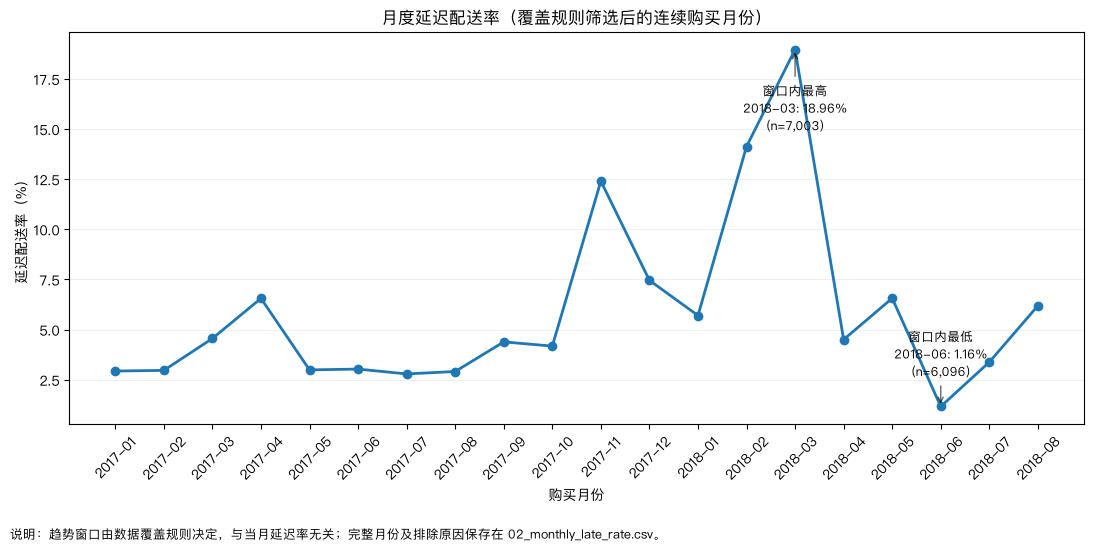

In [22]:
fig, ax = plt.subplots(figsize=(11, 5.5))
trend_plot = trend_months.reset_index()
trend_plot["purchase_month_label"] = trend_plot["purchase_month"].astype(str)

ax.plot(
    trend_plot["purchase_month_label"],
    trend_plot["late_rate_pct"],
    marker="o",
    linewidth=2,
)
ax.set_title("月度延迟配送率（覆盖规则筛选后的连续购买月份）")
ax.set_ylabel("延迟配送率（%）")
ax.set_xlabel("购买月份")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.2)

max_row = trend_plot.loc[trend_plot["late_rate_pct"].idxmax()]
min_row = trend_plot.loc[trend_plot["late_rate_pct"].idxmin()]
for row, label in [(max_row, "窗口内最高"), (min_row, "窗口内最低")]:
    ax.annotate(
        f'{label}\n{row["purchase_month_label"]}: {row["late_rate_pct"]:.2f}%\n(n={int(row["eligible_orders"]):,})',
        xy=(row["purchase_month_label"], row["late_rate_pct"]),
        xytext=(0, -58 if label == "窗口内最高" else 22),
        textcoords="offset points",
        ha="center",
        arrowprops={"arrowstyle": "->", "alpha": 0.6},
        fontsize=9,
    )

fig.text(
    0.01,
    0.01,
    "说明：趋势窗口由数据覆盖规则决定，与当月延迟率无关；完整月份及排除原因保存在 02_monthly_late_rate.csv。",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.05, 1, 1])
monthly_figure_path = FIGURE_DIR / "02_monthly_late_rate.png"
fig.savefig(monthly_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 8. 风险、限制与证据边界

### Denominator consistency

- Overall late rate 的分母始终是全部 eligible orders；
- 月度 late rate 的分母是当月 eligible orders；
- severity 的 `pct_of_eligible_orders` 使用全部 eligible orders，`pct_of_late_orders` 只对 late bands 使用全部 late orders；
- review availability 不参与 Notebook 02 的任何分母。

### Missingness 与 excluded orders

被排除的未送达、取消或日期不完整订单没有被视为 on-time，也没有被插补。它们可能包含重要的负面体验，因此 Notebook 02 的 headline 只描述**有可观测 delivery outcome 的 delivered orders**。

### Multi-seller / multi-category attribution

`analysis_orders` 中仍然存在 multi-seller 和 multi-category orders，但本 notebook 不把订单级 delivery outcome 归因给单个 seller 或 category，也不 join bridge tables。后续 Notebook 04 必须使用 `order_seller_bridge` / `order_category_bridge` 和明确的 pair grain。

### Post-outcome leakage

`order_delivered_customer_date`、`delay_days` 和 `is_late` 都是在结果发生后才可知的字段。在本 notebook 的**回顾性描述分析**中使用它们是合理的；如果未来建立 pre-delivery risk model，这些字段不能直接作为预测输入。

### Small groups 与 time pattern

趋势图只展示通过覆盖规则的连续月份，并保留每月 eligible sample size。小样本月份不会被赋予与大样本月份相同的解释强度。即使某个月的延迟率明显更高或更低，也不能据此确定季节性、内部运营事件或因果根因。

### Reference-project result leakage

参考项目只用于方法结构。Notebook 02 的所有数量、比例、严重程度和月份结果都来自本项目当前 processed files 的重新计算与验证。


In [23]:
# 记录 attribution 风险的规模，但不在本 notebook 做 seller/category 排名。
multi_seller_orders = int(analysis["is_multi_seller"].fillna(False).sum())
multi_category_orders = int(analysis["is_multi_category"].fillna(False).sum())

risk_context = pd.DataFrame([
    {
        "risk_context": "multi_seller_orders_in_eligible_population",
        "orders": multi_seller_orders,
        "interpretation": "存在多卖家订单；Notebook 02 不做单一 seller 责任归因。",
    },
    {
        "risk_context": "multi_category_orders_in_eligible_population",
        "orders": multi_category_orders,
        "interpretation": "存在多品类订单；Notebook 02 不做单一 category 责任归因。",
    },
])
display(risk_context)


,risk_context,orders,interpretation
0,multi_seller_orders_in_eligible_population,1275,存在多卖家订单；Notebook 02 不做单一 seller 责任归因。
1,multi_category_orders_in_eligible_population,780,存在多品类订单；Notebook 02 不做单一 category 责任归因。


## 9. Final validation and saved outputs

最后将关键 runtime checks 汇总成 `02_validation.csv`。Critical check 只要有一项 FAIL，notebook 就停止；数据质量 warning 会被保留并说明，但不会被静默删除。

本 notebook 约定保存：

**Tables**

- `outputs/tables/02_population_audit.csv`
- `outputs/tables/02_date_rule_sensitivity.csv`
- `outputs/tables/02_delivery_baseline_summary.csv`
- `outputs/tables/02_delay_severity.csv`
- `outputs/tables/02_monthly_late_rate.csv`
- `outputs/tables/02_validation.csv`

**Figures**

- `outputs/figures/02_delay_severity.png`
- `outputs/figures/02_monthly_late_rate.png`


In [24]:
required_outputs = [
    TABLE_DIR / "02_population_audit.csv",
    TABLE_DIR / "02_date_rule_sensitivity.csv",
    TABLE_DIR / "02_delivery_baseline_summary.csv",
    TABLE_DIR / "02_delay_severity.csv",
    TABLE_DIR / "02_monthly_late_rate.csv",
    FIGURE_DIR / "02_delay_severity.png",
    FIGURE_DIR / "02_monthly_late_rate.png",
]

missing_outputs = [path for path in required_outputs if not path.exists()]
add_validation(
    "validation 前的 7 个约定输出均已生成",
    len(required_outputs) - len(missing_outputs),
    len(required_outputs),
    not missing_outputs,
    note="; ".join(str(p.relative_to(PROJECT_ROOT)) for p in missing_outputs),
)

validation = pd.DataFrame(validation_rows)
critical_failures = validation[(validation["critical"]) & (validation["status"] != "PASS")]

# 先显示，再 assert；如果失败，reviewer 可以看到具体哪一项没有通过。
display(validation)
assert critical_failures.empty, f"存在关键 validation failure:\n{critical_failures.to_string(index=False)}"

validation_path = TABLE_DIR / "02_validation.csv"
validation.to_csv(validation_path, index=False)
assert validation_path.exists(), "02_validation.csv 保存失败"

print("关键 validation：", (validation.loc[validation["critical"], "status"] == "PASS").sum(), "/", int(validation["critical"].sum()), "PASS")
print("非关键 warnings：", int((validation["status"] == "WARN").sum()))
print("已保存输出：")
for path in [*required_outputs, validation_path]:
    print("-", path.relative_to(PROJECT_ROOT))


,check,value,expected,critical,status,note
0,analysis_orders 当前快照行数,"96,470.000",96470,True,PASS,
1,analysis_orders 一单一行,0.000,0,True,PASS,
2,master_order_table 当前快照行数,"99,441.000",99441,True,PASS,
3,master_order_table 一单一行,0.000,0,True,PASS,
4,eligible 分区订单数,"96,470.000",96470,True,PASS,
5,population 分区完整覆盖 master,"99,441.000",99441,True,PASS,
6,upstream eligibility flag 与重新计算一致,1.000,True,True,PASS,
7,analysis_orders order_id 与 master eligible 集合一致,"96,470.000",96470,True,PASS,
8,analysis_orders 全部为 delivered,0.000,0,True,PASS,
9,analysis_orders 缺 actual delivery timestamp,0.000,0,True,PASS,


关键 validation： 29 / 29 PASS
非关键 warnings： 0
已保存输出：
- outputs/tables/02_population_audit.csv
- outputs/tables/02_date_rule_sensitivity.csv
- outputs/tables/02_delivery_baseline_summary.csv
- outputs/tables/02_delay_severity.csv
- outputs/tables/02_monthly_late_rate.csv
- outputs/figures/02_delay_severity.png
- outputs/figures/02_monthly_late_rate.png
- outputs/tables/02_validation.csv


# Notebook Summary

本 notebook 在 Notebook 01 已验证的一单一行数据基础上，建立了 Olist 历史订单的 **late-delivery baseline**。主分析总体为 **96,470 个** delivered 且 actual / estimated delivery date 均可观测的订单；它们来自 master table 的 **99,441 个**全部订单。未进入该总体的订单没有被当作 on-time。

## 最强的直接数据发现

- 使用主 **calendar-date rule**，共有 **6,534 个订单 late，late-delivery rate 为 6.77%**；89,936 个订单在预计日期当天或之前送达。
- 如果直接比较 raw timestamps，会得到 **7,826 个 late orders（8.11%）**。两种定义相差 **1,292 个同日送达订单，约 1.34 个百分点**，说明日期口径会实质影响 headline KPI。
- 在 late orders 中，**median delay 为 7 天，mean 为 10.62 天，P90 为 22 天**。严重程度并不只集中在轻微晚到，因此后续服务设计可以把 severity 作为需要进一步验证的分层维度，但这些分档本身不是已验证的补偿规则。
- 从购买日计算，eligible orders 的平均实际送达时长为 **12.50 个日历日**，平均记录的预计送达时长为 **24.37 个日历日**。这只是历史履约背景，不等同于 carrier transit time，也不识别责任环节。
- 按覆盖规则自动得到的可比趋势窗口是 **2017-01 至 2018-08，共 20 个月**。窗口内 monthly late rate 存在明显历史波动：**2018-03 为 18.96%（7,003 eligible orders）**，**2018-06 为 1.16%（6,096 eligible orders）**。这些是描述性时间差异，不能单独解释为季节性或某个运营事件造成。

## 对下一阶段意味着什么

Notebook 02 证明了 delivery-date miss 是一个可以稳定定义、量化并按严重程度与时间描述的历史运营现象。下一步应由 **`03_review_impact_analysis.ipynb`** 使用同一套 `is_late` / `delay_days` 定义，检查 delivery outcome 与 customer review score 之间的**关联**，而不是提前把本 notebook 的 operational baseline 写成 CX 因果结论。

## 本 notebook 不证明什么

这里没有证明 late delivery **导致**低评分，没有把订单级延迟归因给单一 seller / category / carrier，也没有证明任何 proactive notification、compensation 或 seller governance intervention 会改善 CX。后续 service design 仍应保持 **Direct Data Analysis → Data-informed Synthesis → Proposed Intervention Requiring Future Validation** 的证据层级。



## How this notebook builds on the reference projects

This notebook follows the reference projects in using late delivery as a measurable post-purchase operational signal. It adopts the defensible calendar-date definition of lateness, examines delay severity, and compares delivery performance over time.

However, all metrics in this notebook are recalculated from this project's validated order-level dataset rather than copied from the reference projects.

## What this notebook adds

This notebook integrates the delivery analysis into a reproducible downstream CX workflow by:

1. reusing the validated one-row-per-order population from Notebook 01;
2. explicitly validating the calendar-date late-delivery rule against the timestamp alternative;
3. keeping numerators, denominators, severity bands, and time-window rules auditable;
4. separating descriptive delivery evidence from later customer-impact analysis;
5. producing reusable outputs for the subsequent review-impact and service-design stages.

The contribution is therefore not a new causal claim about delivery failure. It is a validated and traceable delivery baseline that later notebooks can connect to customer reviews, risk segmentation, and service recovery design.